# Dimensiereductie

Auteurs: Brian van der Bijl (brian.vanderbijl@hu.nl), Tijmen Muller

- Studentnummer:
- Naam:
- Datum:

## Deel I: Principal Component Analysis (PCA)

Het _Principal Component Analysis_ (PCA) algoritme kan gebruikt worden om het aantal dimensies van een dataset te reduceren tot de belangrijkste componenten. Als de originele dataset $n$ dimensies heeft, dan kunnen we met onderstaande stappen dit terugbrengen tot een (zelfgekozen) aantal van $n^\prime$ dimensies.

1. Centreer de data.
2. Bereken de covariantie van alle features onderling. 
3. Bereken de Eigenvectors en Eigenvalues van de covariantiematrix.
4. Kies de $n^\prime$ Eigenvectors om de dimensiereductie mee uit te voeren.
5. Vermenigvuldig de $n^\prime$ Eigenvectors met de originele data om de reductie toe te passen.

### Context

Gegeven is een databestand met embeddings van 200 tekstfragmenten. Elke embedding bestaat in 15 dimensies, en is gelabeled met een categorie. We gaan dimensionaliteitsreductie toepassen om de data te kunnen plotten.

De categorie geeft aan in welk genre de tekstfragmenten thuishoren. Daarnaast is onderscheid gemaakt tussen het perspectief waarin het fragment geschreven is: ik (1st person) of hij/haar/hen (3rd person):
- Fantasy (1st person)
- Fantasy (3rd person)
- Science Fiction (1st person)
- Science Fiction (3rd person)
- Romance (1st person)
- Romance (3rd person)
- Crime (1st person)
- Crime (3rd person)

In [74]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Show floats on 3 digits, suppress scientific notation
np.set_printoptions(precision=3, suppress=True)

In [75]:
with open('data.pkl', 'rb') as file:
    data = pickle.load(file)

data.sample(5)

e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,e_9,e_10,e_11,e_12,e_13,e_14,e_15,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.360303,0.551049,1.165759,1.187112,1.153167,1.563875,0.637725,3.334439,1.066239,0.588193,0.969566,0.627707,0.531832,1.417124,1.107069,"""Science Fiction (1st person)"""
0.518299,1.193492,1.225802,0.289986,0.257209,3.234096,1.518995,1.932752,1.272596,0.45118,1.46671,0.808326,1.127285,1.197591,1.380976,"""Science Fiction (3rd person)"""
0.66742,0.41405,0.27638,1.427912,1.407116,4.864125,1.095754,1.652713,1.019534,0.705374,1.055442,0.989978,1.520906,1.259134,0.353649,"""Romance (3rd person)"""
0.551964,1.525353,0.627704,0.825905,1.28316,6.306758,0.847144,3.285628,1.633838,1.408,1.103728,0.888523,0.940608,1.139474,1.084989,"""Crime (3rd person)"""
0.915823,0.602542,0.565497,1.480469,1.071678,4.684612,0.572062,2.917065,0.956232,1.55782,0.660535,0.888666,0.558431,0.69659,1.062094,"""Crime (1st person)"""


### Voorbereidende opdracht

Gegeven een dataset met $m$ datapunten met elk $n$ features en een gewenste reductie tot $n^\prime$ dimensies. Bepaal voor elk van de vijf stappen van het algoritme wat de dimensies (oftewel `shape`) is van de volgende tussenresultaten:

0. De matrix met de originele dataset.
1. De matrix met de gemiddelden per feature om de data mee te centreren.
2. De covariantiematrix.
3. De matrix met de Eigenvectors en de matrix met de Eigenvalues.
4. De matrix met de _geselecteerde_ Eigenvectors.
5. De matrix met de _gereduceerde_ data.

### Opdracht 1. Implementatie

Schrijf een eigen implementatie van het PCA-algoritme `compute_pca(X, n_components)` volgens eerdergenoemde stappen van het algoritme. Maak slim gebruik van fucties van `numpy` waar mogelijk, maar zorg wel dat je begrijpt wat je in elke stap doet. De laatste stap is al gegeven in de functiedefinitie hieronder.

Hint: Laat bij stap 3. zien (bijvoorbeeld met een `print()` statement) dat de meest informatieve Eigenvalue al meer dan 50% van de informatie bevat van onze dataset.

#### Input
- `X: numpy.array` - numpy matrix met dimensies $(m, n)$; elke rij is een datapunt in $n$ dimensies
- `n_components: int` - het gewenste aantal dimensies $n^\prime$

#### Output
`X_reduced: numpy.array` - een $(m, n^\prime)$ numpy matrix met de gereduceerde data.

In [76]:
def compute_pca(X, n_components, scale=False):
    """
    Parameters
    ----------
    X : numpy.ndarray
        Input data matrix of shape (m, n), where m is the number of samples and n is the number of features.
    n_components : int
        The number of principal components (dimensions) to keep.

    Returns
    -------
    X_reduced : numpy.ndarray
        The data projected onto the top n_components principal components.
    """
    arr = np.array(X)
    
    
    arr -= np.mean(arr, axis=0)
    # print("Mean after centering:", np.mean(arr, axis=0))
   
    # de data schalen geeft een foute antwoord bij de test scenario, wanneer moet ik het wel of niet doen?
    if scale:
        arr /= np.std(arr, axis=0)
        # print("Standard deviation after scaling:", np.std(arr, axis=0))
    
    
    cov_matrix = np.cov(arr, rowvar=False)
    # print("Covariance matrix:\n", cov_matrix)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    sorted_index = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_index]
    eigenvectors = eigenvectors[:, sorted_index]
    
    # print("Eigenvalues:\n", eigenvalues)
    # print("Eigenvectors:\n", eigenvectors)
    print("original variance:", np.sum(eigenvalues))
    print("reduced variance :", np.sum(eigenvalues[:n_components]),"(", np.sum(eigenvalues[:n_components]) / np.sum(eigenvalues), ")")

    n_eigenvectors = eigenvectors[:, :n_components] 
    

    # Stap 5.
    
    x_reduced = arr @ n_eigenvectors
    
    return x_reduced

#### Test-scenario
Onderstaande code zou de volgende output moeten opleveren (het minteken kan wisselen):

```python
[[ 0.43437323 -0.49820384]
 [ 0.42077249  0.50351448]
 [-0.85514571 -0.00531064]]
 ```

In [77]:
np.random.seed(1)
X = np.random.rand(3, 10)

X_reduced = compute_pca(X, n_components=2, scale=False)
print(X_reduced)

original variance: 0.7993829342314344
reduced variance : 0.7993829342314343 ( 0.9999999999999999 )
[[ 0.434  0.498]
 [ 0.421 -0.504]
 [-0.855  0.005]]


### Opdracht 2. Visualisatie met dimensiereductie

Maak op basis van de aangeleverde `data` een numpy array van de datapunten, en gebruik je PCA-implementatie om een 2D- en 3D-weergave van de data te maken. Maak van elke weergave een plot, waarbij iedere categorie een eigen kleur krijgt.

In [78]:
x = data.drop('label')
y = data['label']
print(x)
print(y)

shape: (200, 15)
┌──────────┬──────────┬──────────┬──────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ e_1      ┆ e_2      ┆ e_3      ┆ e_4      ┆ … ┆ e_12     ┆ e_13     ┆ e_14     ┆ e_15     │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ 1.108966 ┆ 0.827991 ┆ 1.627138 ┆ 0.925778 ┆ … ┆ 1.0722   ┆ 0.539163 ┆ 0.620247 ┆ 0.380938 │
│ 1.653362 ┆ 1.554929 ┆ 1.475294 ┆ 0.677498 ┆ … ┆ 1.633079 ┆ 1.049915 ┆ 1.0656   ┆ 0.299805 │
│ 1.225105 ┆ 1.216584 ┆ 1.423586 ┆ 1.248953 ┆ … ┆ 1.344977 ┆ 1.0466   ┆ 1.127903 ┆ 0.689821 │
│ 1.732045 ┆ 1.577317 ┆ 1.555516 ┆ 1.323991 ┆ … ┆ 1.354425 ┆ 0.503422 ┆ 0.952766 ┆ 0.185922 │
│ 1.2672   ┆ 1.169387 ┆ 0.949254 ┆ 0.692989 ┆ … ┆ 1.369123 ┆ 0.383284 ┆ 0.710478 ┆ 0.572426 │
│ …        ┆ …        ┆ …        ┆ …       

original variance: 4.144436304486792
reduced variance : 2.845841932375098 ( 0.6866656218830465 )


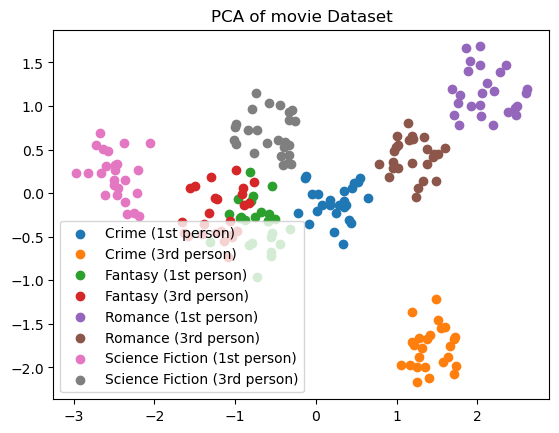

In [79]:
x_2d = compute_pca(x, n_components=2, scale=False)
    

for i in np.unique(y):
    plt.scatter(x_2d[y == i, 0], x_2d[y == i, 1], label=i)
plt.legend()
plt.title('PCA of movie Dataset')
plt.show()

original variance: 4.144436304486792
reduced variance : 3.200235740949684 ( 0.7721763602652282 )


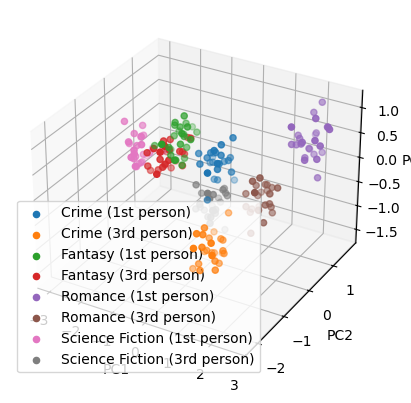

In [80]:
# TODO: Schrijf hier je code.
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

x_3d = compute_pca(x, n_components=3, scale=False)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

labels = np.unique(y)

for label in labels:
    mask = y == label
    ax.scatter(
        x_3d[mask, 0],
        x_3d[mask, 1],
        x_3d[mask, 2],
        label=label
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.legend()
plt.show()


### Opdracht 3. Analyse

Analyseer de resultaten:
1. Welke categorieën zijn op basis van de PCA-reductie te onderscheiden, en welke niet? 
2. Geef aan hoeveel procent van de informatie bewaard is gebleven in 2D en 3D respectievelijk.
3. Hoeveel dimensies zijn nodig om 90% van de informatie te bewaren?
4. En voor 95%?

In [81]:
x_2d = compute_pca(x, n_components=2, scale=True)
x_3d = compute_pca(x, n_components=3, scale=True)
x_90 = compute_pca(x, n_components=10, scale=True)
x_95 = compute_pca(x, n_components=12, scale=True)

original variance: 15.07537688442211
reduced variance : 5.990771195711439 ( 0.3973878226488588 )
original variance: 15.07537688442211
reduced variance : 8.264230045469665 ( 0.5481939263494878 )
original variance: 15.07537688442211
reduced variance : 13.788712752281898 ( 0.9146512792346992 )
original variance: 15.07537688442211
reduced variance : 14.48070078332013 ( 0.9605531519602354 )


1. meeste genres zijn goed te onderscheiden behalve fantasy 1st en 3rd person het is lastig om tussen die twee te onderscheiden
2. 2d: 39.7%, 3d: 54.8%
3. minstens 10 dimensies
4. minstens 12 dimensies

## Deel II: t-Distributed Stochastic Neighbour Embedding (t-SNE)

Een alternatieve methode voor dimensiereductie is _t-Distributed Stochastic Neighbour Embedding_ (t-SNE). 

### Opdracht 4. Toepassing
Gebruik SciKit-Learn om met behulp van t-SNE de data tot 2 dimensies te reduceren en plot het resultaat (wederom met kleuren voor de categorien). 

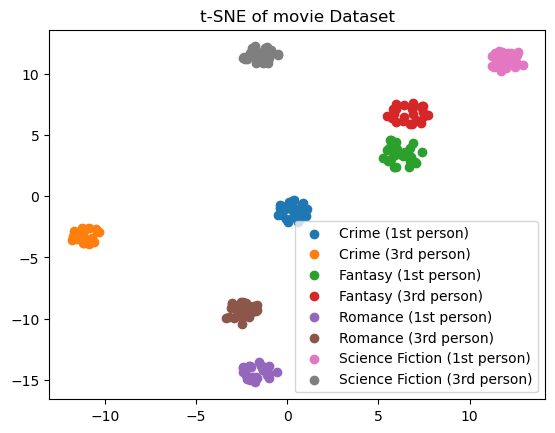

In [82]:
from sklearn.manifold import TSNE
 
x_tsne = TSNE(n_components=2, random_state=42).fit_transform(x) 
for i in np.unique(y):
    plt.scatter(x_tsne[y == i, 0], x_tsne[y == i, 1], label=i)
plt.legend()
plt.title('t-SNE of movie Dataset')
plt.show()

### Opdracht 5. Vergelijking

Vergelijk deze met de resultaten van je PCA-implementatie:

1. Hoe verhoudt de zichtbaarheid van de categorieën zich tussen beide resultaten?
2. Hoe verhouden de algoritmes zich in het behoud van informatie?

Beantwoord de volgende vragen los van de data van deze opdracht:

3. Waarvoor zou je PCA en t-SNE inzetten als je te maken krijgt met een onbekende (mogelijk ongelabelde) dataset?
4. Geef een voorbeeld waar PCA de voorkeur heeft boven t-SNE.
5. Geef een voorbeeld waar t-SNE de voorkeur heeft boven PCA.

1. De t-SNE-implementatie heeft een veel betere zichtbaarheid vergeleken met mijn implementatie van PCA.

2. Mijn implementatie verliest veel informatie bij het reduceren van dimensies. Hierdoor zijn de punten meer verspreid, waardoor de zichtbaarheid van mijn implementatie afneemt. De t-SNE-implementatie van scikit-learn gaat beter om met het behouden van informatie, waardoor de punten dichter bij elkaar liggen.

3. Met deze twee methodes kun je makkelijker patronen en correlaties tussen features zien vanwege de visuele output.

4. Met PCA kun je makkelijker zien welke dimensies belangrijk zijn en hoeveel dimensies je moet behouden.

5. t-SNE is preciezer vergeleken met PCA. Met t-SNE kun je veel makkelijker de correlatie tussen labels zien.

### Opdracht 6. Project

Als het goed is, heb je op dit moment een eerste idee van de data waar je in het project mee gaat werken. Geef antwoord op onderstaande vragen.

1. Wat is de dimensionaliteit waar je mee te maken hebt?
2. Beschrijf hoe dimensionaliteitsreductie-algoritmen je kunnen helpen de data te verkennen.

1. wij gaan werken met afbeeldingen, dus zal de dimensionaliteit afhangen aan hoe groot ons afbeeldeingen zijn (net als 100 X 100 pixels dus 10000 dimensies).
2. wij kunnen waarschijnlijk ons model sneller maken door overbodige dimensies te verwijderen.